In [248]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

### Loading the data

In [249]:
df = pd.read_csv('../data/ethiopia.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## **Data Loading & Date Parsing**

### Add a Country column with the Ethiopia value

In [250]:
df_clean = df.copy()

In [251]:
df_clean["Country"] = "Ethiopia"
df_clean.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


### Convert the YEAR and DOY columns into a proper datetime column

In [252]:
df_clean["Date"] = pd.to_datetime(df_clean["YEAR"] * 1000 + df_clean["DOY"], format="%Y%j")
df_clean.drop(columns=["YEAR", "DOY"], inplace=True)
df_clean.sample(5)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
2965,2023,44,15.55,26.65,6.43,20.22,0.00,32.03,2.89,5.00,77.08,3.78,Ethiopia,2023-02-13
112,2015,113,20.07,30.93,12.12,18.81,0.08,26.48,2.02,4.85,77.01,4.30,Ethiopia,2015-04-23
2643,2022,87,16.87,27.10,8.77,18.33,0.00,55.08,2.92,4.58,77.03,7.33,Ethiopia,2022-03-28
635,2016,271,14.85,19.50,11.87,7.63,5.96,85.11,2.01,3.42,77.06,11.53,Ethiopia,2016-09-27
922,2017,192,15.52,19.59,11.56,8.03,3.00,80.99,1.41,3.41,77.08,11.51,Ethiopia,2017-07-11


### Extract Month as a separate colum

In [272]:
df_clean["Month"] = df_clean["Date"].dt.month
df_clean.sample(5)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2924,14.01,21.76,8.79,12.97,0.30,70.25,3.45,6.47,77.23,8.47,Ethiopia,2023-01-03,1
1376,15.92,23.21,9.74,13.47,0.02,63.77,1.94,3.95,76.97,8.92,Ethiopia,2018-10-08,10
1703,16.68,21.68,11.97,9.71,2.11,77.81,0.89,1.56,76.90,11.88,Ethiopia,2019-08-31,8
3936,13.31,20.38,7.96,12.42,0.21,81.87,2.46,4.51,77.02,9.95,Ethiopia,2025-10-11,10
1449,14.01,24.04,5.79,18.25,0.00,52.86,2.19,3.19,77.11,6.21,Ethiopia,2018-12-20,12


## **Summary Statistics & Missing-Value Report**

#### Replace all occurrences of -999 with np.nan

In [273]:
df_clean.replace(-999, np.nan, inplace=True)
df_clean.sample(5)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
3314,17.32,25.46,10.13,15.33,0.13,69.87,2.84,4.76,77.16,10.45,Ethiopia,2024-01-28,1
3951,15.38,21.45,9.27,12.18,0.56,72.77,0.99,1.97,77.07,10.08,Ethiopia,2025-10-26,10
1303,16.57,22.15,11.47,10.68,3.13,79.20,1.44,2.88,77.15,11.80,Ethiopia,2018-07-27,7
262,16.79,22.33,12.09,10.24,0.45,75.43,1.60,2.96,77.18,11.39,Ethiopia,2015-09-20,9
3985,12.54,21.70,4.86,16.84,0.00,66.36,2.18,3.33,77.04,7.24,Ethiopia,2025-11-29,11


In [274]:
df_clean.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Handle duplicate rows

In [275]:
# drop any duplicate rows
df_clean.duplicated().sum()


0

In [276]:
df_clean.describe()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## **Outlier Detection & Basic Cleaning**

### Detect outliers using z-score

In [278]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df_clean[cols_to_check]))

In [279]:
outliers_mask=(z_scores>3).any(axis=1)
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 132


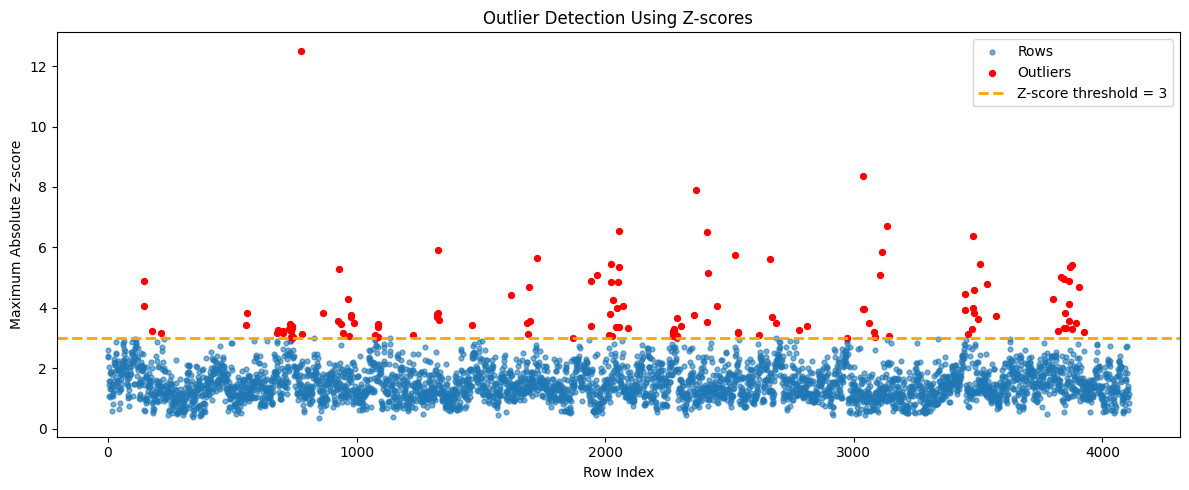

In [280]:
max_z = np.abs(z_scores).max(axis=1)

plt.figure(figsize=(12, 5))
plt.scatter(df_clean.index, max_z, s=12, alpha=0.6, label="Rows")
plt.scatter(df_clean.index[outliers_mask], max_z[outliers_mask], color="red", s=18, label="Outliers")
plt.axhline(3, color="orange", linestyle="--", linewidth=2, label="Z-score threshold = 3")
plt.title("Outlier Detection Using Z-scores")
plt.xlabel("Row Index")
plt.ylabel("Maximum Absolute Z-score")
plt.legend()
plt.tight_layout()
plt.show()

### 🧹 Outlier Handling Strategy

Outliers were identified using Z-scores, with a threshold of (|Z| > 3). Rather than removing all outliers indiscriminately, a domain-aware approach was applied to distinguish between data errors, noise, and meaningful extreme weather events.

#### 1. Dropping Invalid Observations

Rows were **dropped** only when they violated known physical or logical constraints:

* ( T2M_MAX < T2M_MIN )
* ( T2M_RANGE \neq T2M_MAX - T2M_MIN )
* Relative humidity ((RH2M)) outside the range ([0, 100])
* Negative wind speed values

These represent data inconsistencies or measurement errors rather than true outliers.
In our case no such data was found. 

---

#### 2. Retaining Multi-variable Outliers

Rows where **two or more variables simultaneously exceeded the Z-score threshold** were **retained**. These accounted for approximately **1% of the dataset (6 rows)**.

These observations are likely to represent **real meteorological events**, such as:

* Storms (e.g., high wind speed and high precipitation)
* Temperature anomalies (e.g., unusually hot or cold days)

For example, **3 rows were identified as storm events**, characterized by concurrent high values in `WS2M_MAX` and `PRECTOTCORR`. Such patterns are physically meaningful and should be preserved.
we have also seen all outliers might be rearly extreme values so the data outliers were all retained.

---

#### 3. Capping Single-variable Outliers

Rows where **only one variable exceeded the Z-score threshold** were treated as potential noise or measurement spikes. Instead of removing these rows, the extreme values were **capped** using percentile-based clipping (1st and 99th percentiles).

This approach:

* Reduces the impact of extreme values on analysis and modeling
* Preserves the overall structure and continuity of the dataset

In the data there were no single variable outliers

---

#### **Final Strategy Summary**

| Category                               | Action     | Rationale          |
| -------------------------------------- | ---------- | ------------------ |
| Physically inconsistent values         | **Drop**   | Data errors        |
| Multi-variable outliers (≥2 variables) | **Retain** | Likely real events |
| Single-variable outliers               | **Cap**    | Likely noise       |

---

This approach ensures that important extreme weather patterns are preserved while minimizing the influence of erroneous or noisy data points.


In [290]:
outlier_counts = pd.Series((z_scores > 3).sum(axis=0), index=cols_to_check)
total_rows_per_col = df_clean[cols_to_check].notna().sum(axis=0)

outlier_counts = pd.DataFrame({
    "Outlier_Count": outlier_counts,
    "Outlier_Percentage (%)": (outlier_counts / total_rows_per_col) * 100
})

print(outlier_counts)

             Outlier_Count  Outlier_Percentage (%)
T2M                      3                0.073028
T2M_MAX                  0                0.000000
T2M_MIN                 18                0.438169
PRECTOTCORR             95                2.312561
RH2M                    13                0.316456
WS2M                     3                0.073028
WS2M_MAX                 5                0.121714


### Detecting Invalid Observations

In [291]:
# Data quality checks
humidity_col = "RH2M" if "RH2M" in df_clean.columns else "Humidity"
wind_col = "WS2M" if "WS2M" in df_clean.columns else "Wind speed"

checks = pd.DataFrame(index=df_clean.index)

# 1) T2M_MAX < T2M_MIN
checks["T2M_MAX_lt_T2M_MIN"] = df_clean["T2M_MAX"] < df_clean["T2M_MIN"]

# 2) T2M_RANGE != T2M_MAX - T2M_MIN
expected_range = df_clean["T2M_MAX"] - df_clean["T2M_MIN"]
checks["T2M_RANGE_mismatch"] = ~np.isclose(df_clean["T2M_RANGE"], expected_range, equal_nan=True)

# 3) Humidity < 0 or > 100
checks["Humidity_out_of_bounds"] = (df_clean[humidity_col] < 0) | (df_clean[humidity_col] > 100)

# 4) Wind speed < 0
checks["Wind_speed_negative"] = df_clean[wind_col] < 0

# Combine and report
checks["any_issue"] = checks.any(axis=1)

print("Issue counts by rule:")
print(checks.drop(columns="any_issue").sum())

print(f"\nTotal rows with at least one issue: {checks['any_issue'].sum()}")

# Show problematic rows with relevant columns
problem_rows = df_clean.loc[
    checks["any_issue"],
    [c for c in ["Date", "T2M_MIN", "T2M_MAX", "T2M_RANGE", humidity_col, wind_col] if c in df_clean.columns]
].copy()

problem_rows["T2M_MAX_lt_T2M_MIN"] = checks.loc[checks["any_issue"], "T2M_MAX_lt_T2M_MIN"].values
problem_rows["T2M_RANGE_mismatch"] = checks.loc[checks["any_issue"], "T2M_RANGE_mismatch"].values
problem_rows["Humidity_out_of_bounds"] = checks.loc[checks["any_issue"], "Humidity_out_of_bounds"].values
problem_rows["Wind_speed_negative"] = checks.loc[checks["any_issue"], "Wind_speed_negative"].values

if not problem_rows.empty:
    print(problem_rows.head(10))

Issue counts by rule:
T2M_MAX_lt_T2M_MIN        0
T2M_RANGE_mismatch        0
Humidity_out_of_bounds    0
Wind_speed_negative       0
dtype: int64

Total rows with at least one issue: 0


In [283]:
df_temp = df_clean.copy()

In [284]:
df_temp["is_outlier"] = outliers_mask
df_temp["outlier_count"] = df_temp[cols_to_check].apply(lambda row: (row > 3).sum(), axis=1)

### Detect Multi-variable Outliers

In [285]:
T2M_idx = cols_to_check.index("T2M")
T2M_MAX_idx = cols_to_check.index("T2M_MAX")
T2M_MIN_idx = cols_to_check.index("T2M_MIN")
WS2M_MAX_idx = cols_to_check.index("WS2M_MAX")
PRECTOTCORR_idx = cols_to_check.index("PRECTOTCORR")
RH2M_idx = cols_to_check.index("RH2M")

df_temp["heatwave_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, T2M_idx] > 2) &
    (z_scores[:, T2M_MAX_idx] > 2) &
    (z_scores[:, T2M_MIN_idx] > 2)
)

df_temp["storm_flag"] = (
    df_temp["is_outlier"] &
    (z_scores[:, WS2M_MAX_idx] > 2) &
    (z_scores[:, PRECTOTCORR_idx] > 2) &
    (df_temp["RH2M"] > 70)
)

In [286]:
heatwaves = df_temp["heatwave_flag"].sum()
storms = df_temp["storm_flag"].sum()
print("Number of heatwave days:", heatwaves)
print("Number of Storm days:", storms)

Number of heatwave days: 0
Number of Storm days: 3


In [287]:
outlier_mask = df_temp["is_outlier"]
outlier_df = df_temp.loc[outlier_mask]

# Run consistency checks only on outlier rows
temp_consistency = (
    (outlier_df["T2M_MIN"] <= outlier_df["T2M"]) &
    (outlier_df["T2M"] <= outlier_df["T2M_MAX"]) &
    (np.abs(outlier_df["T2M_RANGE"] - (outlier_df["T2M_MAX"] - outlier_df["T2M_MIN"])) < 1e-3)
)

wind_consistency = outlier_df["WS2M"] <= outlier_df["WS2M_MAX"]
humidity_consistency = (outlier_df["RH2M"] >= 0) & (outlier_df["RH2M"] <= 100)

p95_rain = outlier_df["PRECTOTCORR"].quantile(0.95)
storm_consistency = ~(
    (outlier_df["PRECTOTCORR"] > p95_rain) &
    (outlier_df["RH2M"] < 30)  # suspicious: heavy rain but very dry air
)

relationship_valid_outliers = (
    temp_consistency &
    wind_consistency &
    humidity_consistency &
    storm_consistency
)

# Map back to full index (non-outliers set to False)
relationship_valid = pd.Series(False, index=df_temp.index)
relationship_valid.loc[outlier_df.index] = relationship_valid_outliers

# Keep multi-variable logic within outliers only
multi_mask = outlier_mask & (df_temp["outlier_count"] >= 2)

valid_multi = multi_mask & relationship_valid
invalid_multi = multi_mask & ~relationship_valid

print("Outlier rows checked:", outlier_mask.sum())
print("Valid multi-variable outliers:", valid_multi.sum())
print("Invalid multi-variable outliers:", invalid_multi.sum())

Outlier rows checked: 132
Valid multi-variable outliers: 132
Invalid multi-variable outliers: 0


## Handle remaining missing values

In [292]:
# check missing values
df_clean.isna().sum()

T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

## Export the cleaned DataFrame

In [294]:
df_clean.head()

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [293]:
os.makedirs("data", exist_ok=True)

country = "ethiopia"
output_path = f"data/{country}_clean.csv"

df_clean.to_csv(output_path, index=False)

print(f"Cleaned data saved to: {output_path}")

Cleaned data saved to: data/ethiopia_clean.csv


# **Time Series Analysis**

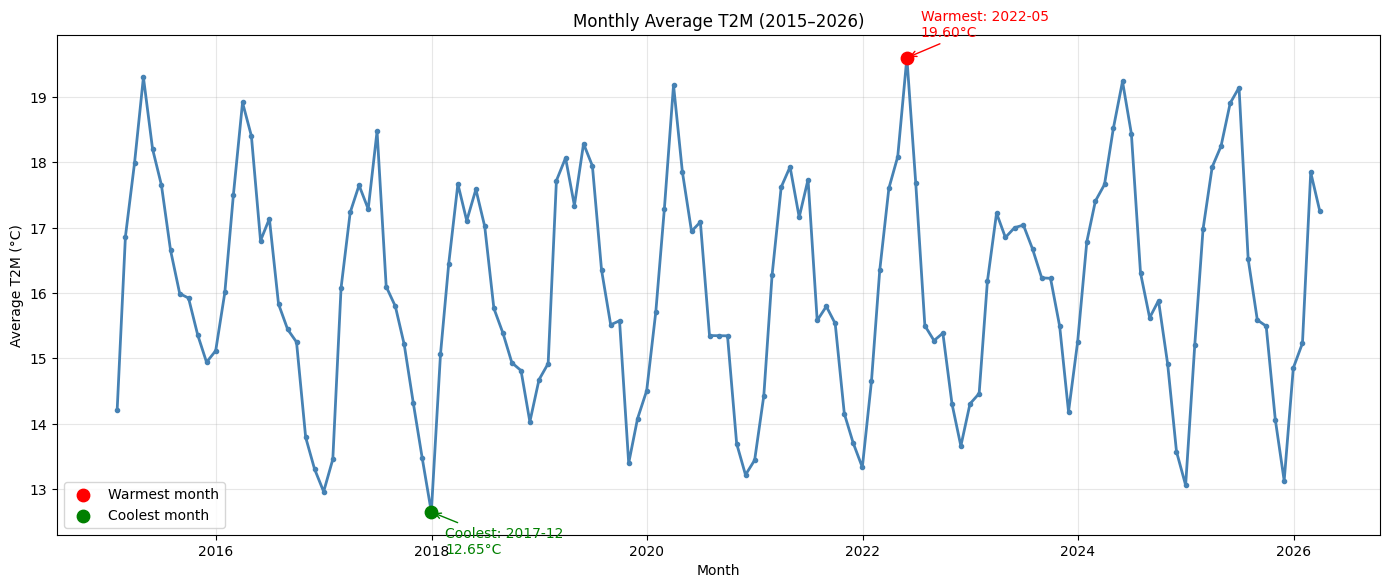

In [296]:
monthly_avg_t2m = df_clean.set_index("Date")["T2M"].resample("ME").mean()

warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(monthly_avg_t2m.index, monthly_avg_t2m.values, color="steelblue", linewidth=2, marker="o", markersize=3)

plt.scatter([warmest_month], [monthly_avg_t2m[warmest_month]], color="red", s=80, zorder=5, label="Warmest month")
plt.scatter([coolest_month], [monthly_avg_t2m[coolest_month]], color="green", s=80, zorder=5, label="Coolest month")

plt.annotate(
    f"Warmest: {warmest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[warmest_month]:.2f}°C",
    xy=(warmest_month, monthly_avg_t2m[warmest_month]),
    xytext=(10, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.annotate(
    f"Coolest: {coolest_month.strftime('%Y-%m')}\n{monthly_avg_t2m[coolest_month]:.2f}°C",
    xy=(coolest_month, monthly_avg_t2m[coolest_month]),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="green"),
    color="green"
)

plt.title("Monthly Average T2M (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

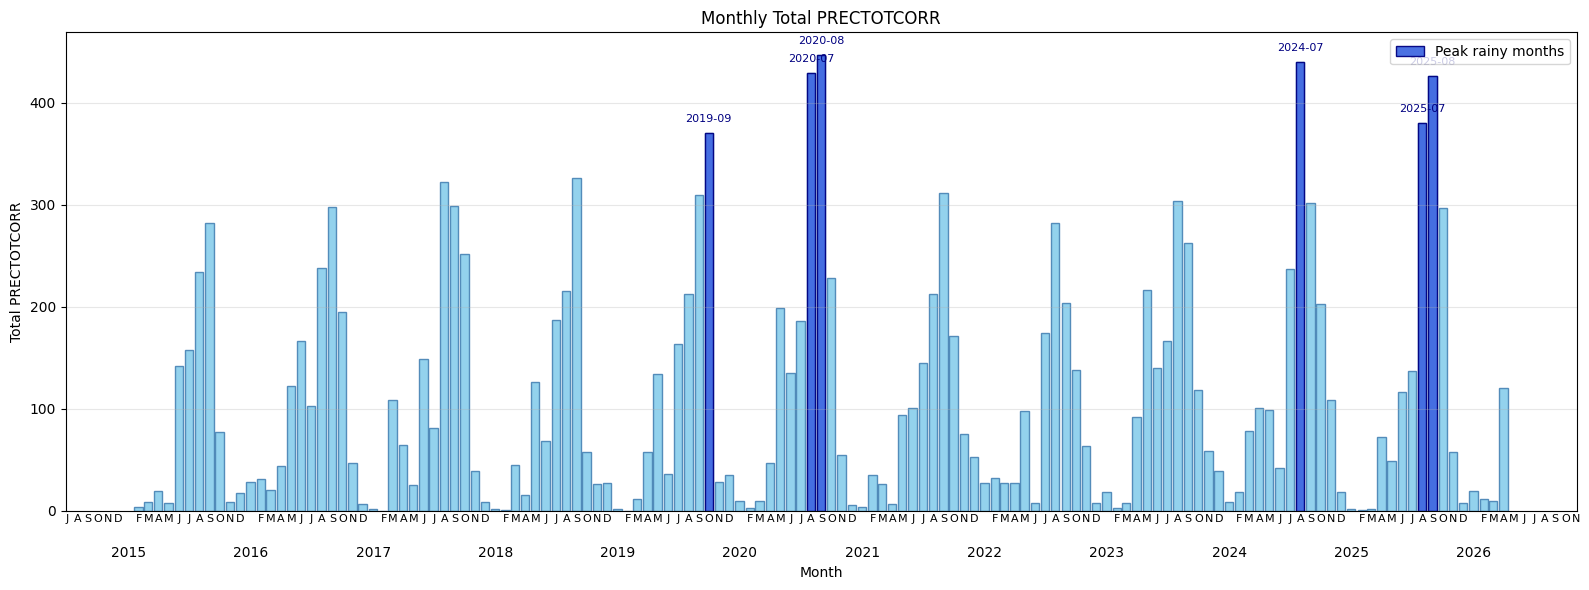

Peak rainy-season months (highest monthly totals):
Date
2019-09-30    370.32
2020-07-31    429.02
2020-08-31    446.65
2024-07-31    440.28
2025-07-31    380.30
2025-08-31    425.83
Name: PRECTOTCORR, dtype: float64


In [310]:
from matplotlib.ticker import FuncFormatter

import matplotlib.dates as mdates

# Monthly total precipitation (PRECTOTCORR)
monthly_total_prectotcorr = df_clean.set_index("Date")["PRECTOTCORR"].resample("ME").sum()

# Pick peak rainy-season months (top 6 wettest months in the full time series)
peak_months = monthly_total_prectotcorr.nlargest(6).sort_index()

plt.figure(figsize=(16, 6))
plt.bar(
    monthly_total_prectotcorr.index,
    monthly_total_prectotcorr.values,
    width=25,
    color="skyblue",
    edgecolor="steelblue",
    alpha=0.9
)

# Highlight and annotate peak months
plt.bar(
    peak_months.index,
    peak_months.values,
    width=25,
    color="royalblue",
    edgecolor="navy",
    alpha=0.95,
    label="Peak rainy months"
)

for dt, val in peak_months.items():
    plt.annotate(
        dt.strftime("%Y-%m"),
        xy=(dt, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="navy"
    )

ax = plt.gca()

# Year label every year
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("\n%Y"))

# Month labels as first letter (J, F, M, ...)
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_minor_formatter(
    FuncFormatter(lambda x, pos: mdates.num2date(x).strftime("%b")[0])
)

ax.tick_params(axis="x", which="major", length=0, pad=14, labelsize=10)
ax.tick_params(axis="x", which="minor", length=0, pad=2, labelsize=8)

plt.title("Monthly Total PRECTOTCORR")
plt.xlabel("Month")
plt.ylabel("Total PRECTOTCORR")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Peak rainy-season months (highest monthly totals):")
print(peak_months)